## Notebook 6: Model Explainability with SHAP

Accurate predictions alone are not sufficient in credit risk modeling. Lending decisions often require transparency, accountability, and explainability.

This notebook uses SHAP (SHapley Additive exPlanations) to understand how individual features influence RiskLens predictions.

The objective is to answer two key questions:

1. Which features drive default risk across the portfolio?
2. Why did RiskLens assign a particular risk score to a specific applicant?

By combining probability estimates, decision rules, and feature-level explanations, RiskLens moves beyond prediction and becomes an explainable credit risk decisioning system.

In [ ]:
import shap,joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from decision_functions import assign_decision,assign_risk_band


## Load Model and Evaluation Data

Load the selected model and evaluation dataset used throughout the RiskLens pipeline.

These assets will be used to generate both global and applicant-level explanations.

In [ ]:
x_test=pd.read_csv('x_test_processed.csv')
y_test=pd.read_csv('y_test.csv').squeeze()

best_model=joblib.load("best_baseline_model.pkl")
best_threshold=joblib.load("best_business_threshold.pkl")

In [ ]:
default_probabilities=best_model.predict_proba(x_test)[:,1]
default_probabilities[:10]


array([0.04729249, 0.03637318, 0.05895396, 0.12535161, 0.08177067,
       0.02158387, 0.30278365, 0.07618759, 0.24721703, 0.14755223])

## Initialize SHAP Explainer

Create a SHAP explainer capable of decomposing model predictions into individual feature contributions.

SHAP values allow us to understand how each feature increases or decreases estimated default risk.

In [ ]:
explainer=shap.TreeExplainer(best_model)


## Compute SHAP Values

Calculate SHAP values for a representative sample of applicants.

These values quantify the contribution of each feature to the model's prediction.

In [ ]:
x_test_sample= x_test.sample(1000,random_state=42)

shap_values=explainer.shap_values(x_test_sample)


In [ ]:
print(type(shap_values))
print(np.array(shap_values).shape)
x_test_sample.shape


<class 'numpy.ndarray'>
(1000, 31)


(1000, 31)

## Global Feature Importance

Identify the features that have the greatest overall influence on RiskLens predictions.

This provides a portfolio-level view of model behavior.

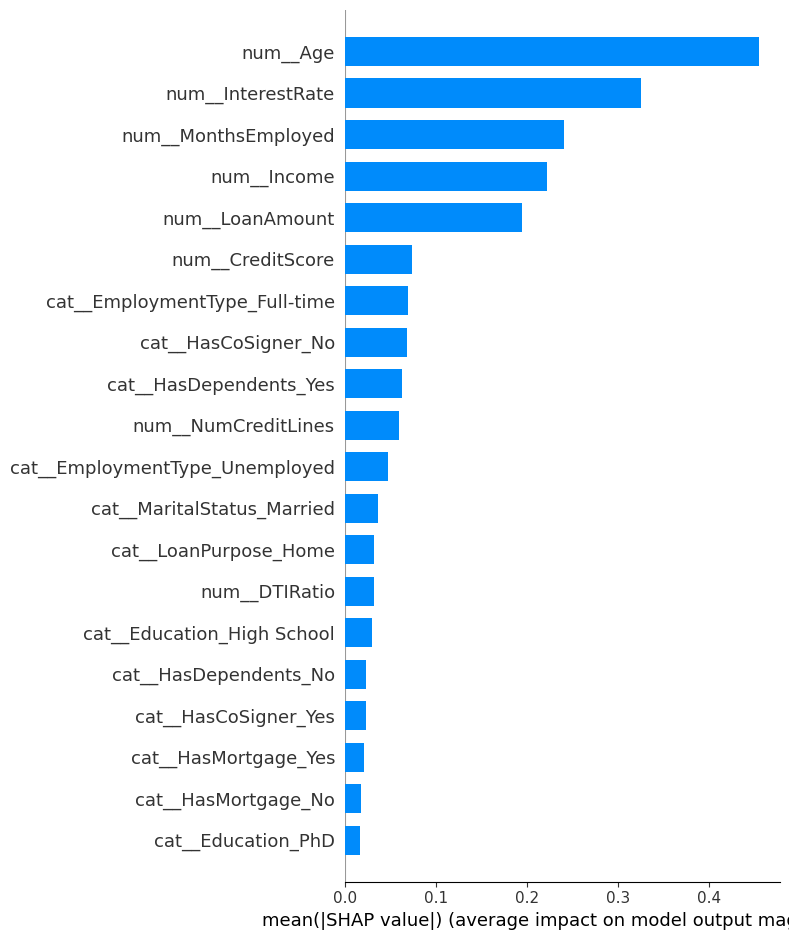

In [ ]:
shap.summary_plot(shap_values,
                  x_test_sample,
                  plot_type="bar")

### Finding: Credit Risk Is Driven by a Small Set of Key Features

The SHAP feature importance analysis reveals that a relatively small group of features contributes most strongly to model predictions.

Features such as Age,Interest Rate,Income, and Employment History appear among the most influential risk drivers.

This suggests that RiskLens is focusing on financially meaningful signals rather than arbitrary patterns.

## Feature Impact Analysis

While feature importance indicates which variables matter most, it does not show how they influence risk.

The SHAP summary plot reveals both the magnitude and direction of feature effects.

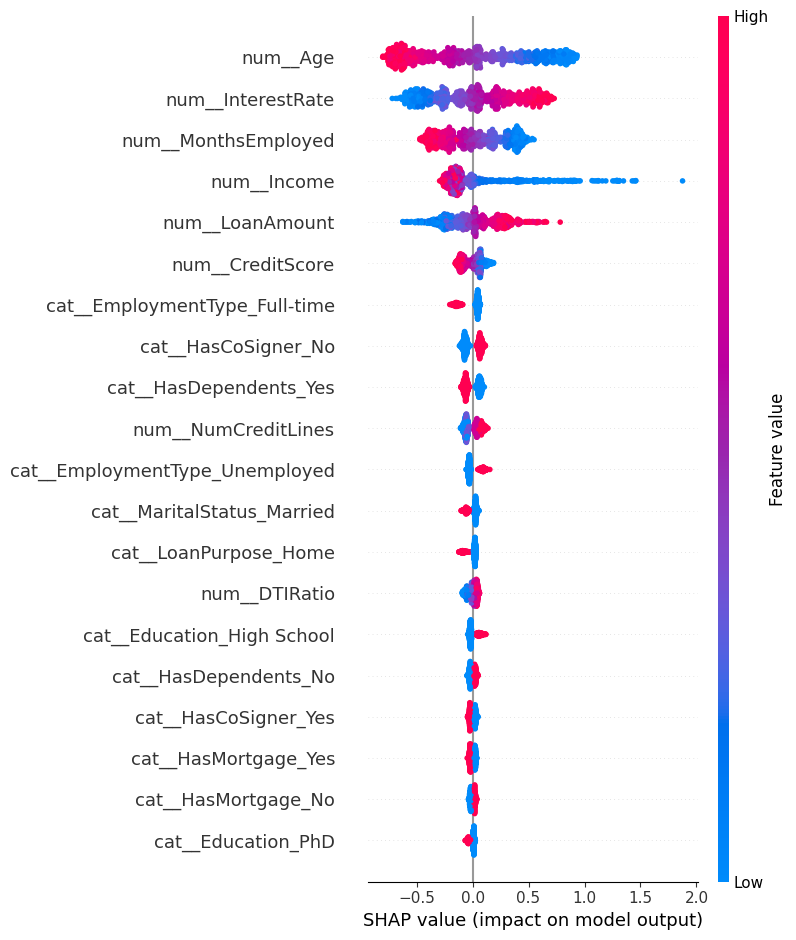

In [ ]:
shap.summary_plot(shap_values,
                  x_test_sample,
                  )

## 6. Applicant-Level Explainability

Portfolio-level explanations are useful, but lending decisions are made at the individual applicant level.

The following analysis explains why RiskLens assigned a particular risk score to a specific borrower.

In [ ]:
applicant_index=0

applicant_data=x_test_sample.iloc[applicant_index]
applicant_shap_values=shap_values[applicant_index]


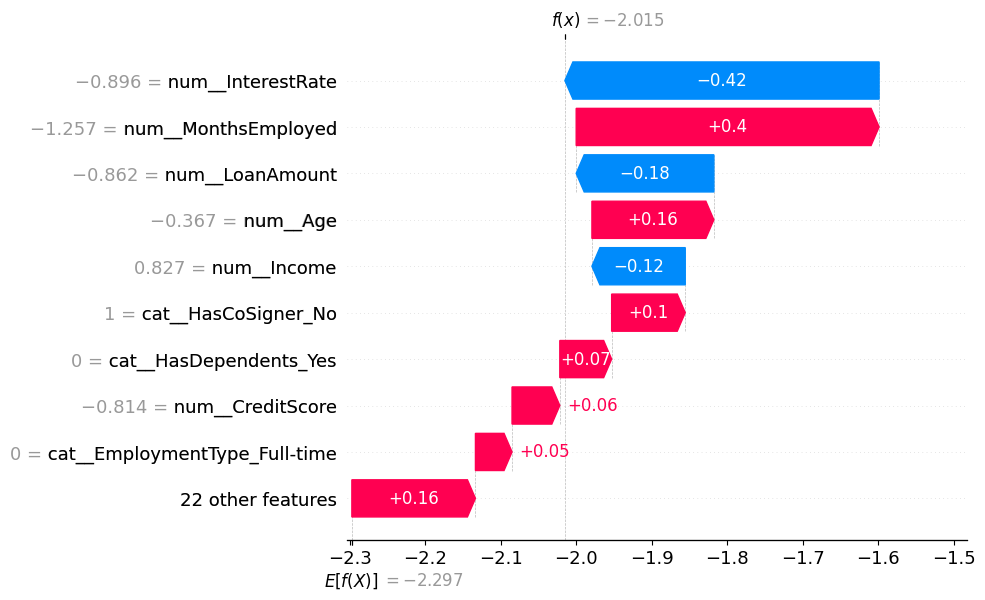

In [ ]:
base_value=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
shap.plots.waterfall(
    shap.Explanation(
        values=applicant_shap_values,
        base_values=base_value,
        data=applicant_data,
        feature_names=x_test_sample.columns
    )
)

### Finding: Risk Predictions Can Be Decomposed Into Individual Drivers

The waterfall plot demonstrates how each feature contributes to the final default probability.

Rather than producing a black-box prediction, RiskLens can identify the specific factors that increased or decreased an applicant's risk score.

In [ ]:
shap_df=pd.DataFrame(
    {
        "Feature": x_test_sample.columns,
        "SHAP_Value": applicant_shap_values,
        "Feature_Value":applicant_data.values
    }

)

shap_df.head()

,Feature,SHAP_Value,Feature_Value
0,num__Age,0.161619,-0.367494
1,num__Income,-0.123683,0.826642
2,num__LoanAmount,-0.182465,-0.861715
3,num__CreditScore,0.063314,-0.814150
4,num__MonthsEmployed,0.401410,-1.257133


## Top Risk Drivers

Identify the features that contributed most strongly toward increasing default risk for the selected applicant.

In [ ]:
top_risk_drivers=shap_df.sort_values(
    by="SHAP_Value",
    ascending=False
).head(10)

top_risk_drivers

,Feature,SHAP_Value,Feature_Value
4,num__MonthsEmployed,0.401410,-1.257133
0,num__Age,0.161619,-0.367494
29,cat__HasCoSigner_No,0.097532,1.000000
23,cat__HasDependents_Yes,0.068706,0.000000
3,num__CreditScore,0.063314,-0.814150
13,cat__EmploymentType_Full-time,0.048507,0.000000
8,num__DTIRatio,0.047857,1.686099
30,cat__HasCoSigner_Yes,0.039242,0.000000
18,cat__MaritalStatus_Married,0.026158,0.000000
21,cat__HasMortgage_Yes,0.022877,0.000000


### Interpretation

The features listed above were the primary contributors to elevated risk for this applicant.

These variables pushed the prediction toward a higher probability of default and influenced the final lending decision.

## Protective Factors

Identify the features that contributed most strongly toward reducing default risk.

In [ ]:
top_protective_factors =shap_df.sort_values(
    by="SHAP_Value",
    ascending=True
).head(10)

top_protective_factors

,Feature,SHAP_Value,Feature_Value
6,num__InterestRate,-0.416360,-0.896050
2,num__LoanAmount,-0.182465,-0.861715
1,num__Income,-0.123683,0.826642
16,cat__EmploymentType_Unemployed,-0.026263,0.000000
5,num__NumCreditLines,-0.025414,-0.449335
10,cat__Education_High School,-0.013453,0.000000
25,cat__LoanPurpose_Business,-0.000911,0.000000
24,cat__LoanPurpose_Auto,-0.000122,0.000000
19,cat__MaritalStatus_Single,0.000000,0.000000
15,cat__EmploymentType_Self-employed,0.000000,0.000000


### Interpretation

These features acted as protective factors and reduced the applicant's estimated risk.

Although they may not have been sufficient to fully offset risk drivers, they provide useful context for credit analysts reviewing the application.

## Human-Readable Explanation Report

Generate a consolidated explanation report that combines:

- Default Probability
- Risk Band
- Lending Decision
- Risk Drivers
- Protective Factors

This represents the final explainability layer of RiskLens.

In [ ]:
def generate_explanation_report(index):
  applicant_probability=best_model.predict_proba(x_test_sample.iloc[[index]])[:,1][0]
  risk_band=assign_risk_band(applicant_probability)
  decision=assign_decision(risk_band)

  applicant_data=x_test_sample.iloc[index]
  applicant_shap_values=shap_values[index]

  explanation_df=pd.DataFrame(
    {
        "Feature": x_test_sample.columns,
        "SHAP_Value": applicant_shap_values,
        "Feature_Value":applicant_data.values
    }

  )

  risk_drivers=explanation_df.sort_values(
    by="SHAP_Value",
    ascending=False
  ).head(5)

  protective_factors=explanation_df.sort_values(
    by="SHAP_Value",
    ascending=True
  ).head(5)


  report={
      "Applicant_Index": index,
      "Default_probability": round(applicant_probability,4),
      "Risk_Band": risk_band,
      "Decision": decision,
      "Top_Risk_Drivers": risk_drivers,
      "Top_Protective_Factors": protective_factors
  }

  return report


In [ ]:
report  =generate_explanation_report(0)

report

{'Applicant_Index': 0,
 'Default_probability': np.float64(0.1176),
 'Risk_Band': 'Moderate Risk',
 'Decision': 'Manual Review',
 'Top_Risk_Drivers':                    Feature  SHAP_Value  Feature_Value
 4      num__MonthsEmployed    0.401410      -1.257133
 0                 num__Age    0.161619      -0.367494
 29     cat__HasCoSigner_No    0.097532       1.000000
 23  cat__HasDependents_Yes    0.068706       0.000000
 3         num__CreditScore    0.063314      -0.814150,
 'Top_Protective_Factors':                            Feature  SHAP_Value  Feature_Value
 6                num__InterestRate   -0.416360      -0.896050
 2                  num__LoanAmount   -0.182465      -0.861715
 1                      num__Income   -0.123683       0.826642
 16  cat__EmploymentType_Unemployed   -0.026263       0.000000
 5              num__NumCreditLines   -0.025414      -0.449335}

## Key Findings

- SHAP analysis identified the primary features driving default risk predictions.
- Feature importance rankings aligned with established credit risk intuition.
- Applicant-level explanations revealed the specific factors influencing individual risk scores.
- RiskLens can distinguish between risk-increasing and risk-reducing factors for each borrower.
- Explainability analysis demonstrated that model decisions are grounded in meaningful financial signals.

RiskLens now provides:

✓ Default Probability Estimation

✓ Business-Driven Threshold Optimization

✓ Risk Segmentation

✓ Lending Decisions

✓ Applicant Recommendations

✓ Model Explainability

The project has evolved from a predictive model into an explainable credit risk decisioning system.